In [4]:
import pandas as pd

df = pd.read_csv("nytcrosswordspure.csv", encoding="latin-1")  # or encoding="cp1252"
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 781573, Columns: 3


In [5]:
# Filter rows containing "-across" or "-down" in the Clue column
filtered_df = df[df['Clue'].str.contains('-across|-down', case=False, na=False)]
print(filtered_df)

              Date      Word                                  Clue
174     10/30/2021       TSP      One of 768 in a 35-Across: Abbr.
216     10/29/2021      AFRO                  Hairstyle for 2-Down
269     10/28/2021       MIL  Ending for some government 37-Across
286     10/28/2021     PINKY      With 13-Down, playground promise
301     10/28/2021     SWEAR                         See 68-Across
...            ...       ...                                   ...
780276   12/6/1993   CORNELL                         One 39-Across
780281   12/6/1993     BROWN                         One 39-Across
780291   12/6/1993  COLUMBIA                         One 39-Across
780307   12/6/1993      YALE                         One 39-Across
780775  11/30/1993      NUDE                        Like 52-Across

[9121 rows x 3 columns]


In [6]:
# Remove rows that are in filtered_df from df
df = df.drop(filtered_df.index)

print(f"Updated file saved. Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Updated file saved. Rows: 772452, Columns: 3


In [7]:
df

,Date,Word,Clue
0,10/31/2021,PAT,"Action done while saying ""Good dog"""
1,10/31/2021,RASCALS,Mischief-makers
2,10/31/2021,PEN,It might click for a writer
3,10/31/2021,SEP,Fall mo.
4,10/31/2021,ECO,Kind to Mother Nature
...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton
781569,11/21/1993,SHRED,Bit
781570,11/21/1993,NEA,Teachers' org.
781571,11/21/1993,BEG,Petition


In [8]:
# Ensure Word is clean text (optional but recommended)
df["Word"] = df["Word"].astype(str).str.strip()

# 1) Length of the word
df["Word_Length"] = df["Word"].str.len()

# 2) Total number of appearances of the Word (regardless of Clue)
df["Word_Appearances"] = df.groupby("Word")["Word"].transform("size")

df.head()


,Date,Word,Clue,Word_Length,Word_Appearances
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135
1,10/31/2021,RASCALS,Mischief-makers,7,7
2,10/31/2021,PEN,It might click for a writer,3,153
3,10/31/2021,SEP,Fall mo.,3,63
4,10/31/2021,ECO,Kind to Mother Nature,3,292


In [14]:
top_unique = (
    df.sort_values("Word_Appearances", ascending=False)
      .drop_duplicates(subset=["Word"], keep="first")
)

top_unique[["Word", "Word_Appearances", "Word_Length"]].head(50)


,Word,Word_Appearances,Word_Length
373266,ERA,631,3
446854,AREA,524,4
365438,ERE,506,3
364505,ELI,484,3
606528,ORE,475,3
219591,ATE,471,3
219629,ALE,469,3
189335,ONE,466,3
726467,ETA,458,3
553726,ALI,436,3


In [10]:
top_word_clue_unique = (
    df.groupby(["Word", "Clue"], as_index=False)
      .size()
      .rename(columns={"size": "Word_Clue_Appearances"})
      .sort_values("Word_Clue_Appearances", ascending=False)
)

top_word_clue_unique[["Word", "Clue", "Word_Clue_Appearances"]].head(50)

,Word,Clue,Word_Clue_Appearances
19428,ALAI,Jai ___,122
11734,AER,___ Lingus,88
145653,EERO,Architect Saarinen,74
241127,IRAE,"""Dies ___""",68
277089,LOA,Mauna ___,66
110464,CRO,___-Magnon,66
55224,ASTO,Regarding,65
466931,SRI,___ Lanka,64
524047,UMA,Actress Thurman,64
324016,NOR,Neither's partner,55


In [11]:
# Parse Date to real datetime (keep your original Date column if you want)
df["Date_dt"] = pd.to_datetime(df["Date"], errors="coerce")

# Latest appearance of the Word (based on Date)
df["Word_Latest_Appearance"] = df.groupby("Word")["Date_dt"].transform("max")

# (optional) if you want it displayed like your original format
df["Word_Latest_Appearance"] = df["Word_Latest_Appearance"].dt.strftime("%m/%d/%Y")

In [13]:
top_word_unique = (
    df.assign(Date_dt=pd.to_datetime(df["Date"], errors="coerce"))
      .groupby("Word", as_index=False)
      .agg(
          Word_Appearances=("Word", "size"),
          Word_Length=("Word", "first"),
          Word_Latest_Appearance=("Date_dt", "max"),
      )
      .sort_values("Word_Appearances", ascending=False)
)

top_word_unique.head(50)

,Word,Word_Appearances,Word_Length,Word_Latest_Appearance
17627,ERA,631,ERA,2021-10-25
3630,AREA,524,AREA,2021-10-26
17655,ERE,506,ERE,2021-10-14
16615,ELI,484,ELI,2021-10-14
39295,ORE,475,ORE,2021-09-15
4594,ATE,471,ATE,2021-10-23
1783,ALE,469,ALE,2021-09-20
38513,ONE,466,ONE,2021-10-27
18023,ETA,458,ETA,2021-10-27
1886,ALI,436,ALI,2021-10-12


In [15]:
import pandas as pd

# Clean + parse date (recommended)
df["Word"] = df["Word"].astype(str).str.strip()
df["Clue"] = df["Clue"].astype(str).str.strip()
df["Date_dt"] = pd.to_datetime(df["Date"], errors="coerce")

# Latest appearance for each Word+Clue pairing
df["Word_Clue_Latest_Appearance"] = df.groupby(["Word", "Clue"])["Date_dt"].transform("max")

# (optional) format display
df["Word_Clue_Latest_Appearance"] = df["Word_Clue_Latest_Appearance"].dt.strftime("%m/%d/%Y")


In [16]:
top_word_clue_unique = (
    df.groupby(["Word", "Clue"], as_index=False)
      .agg(
          Word_Clue_Appearances=("Date_dt", "size"),
          Word_Clue_Latest_Appearance=("Date_dt", "max"),
      )
      .sort_values("Word_Clue_Appearances", ascending=False)
)

# optional formatting
top_word_clue_unique["Word_Clue_Latest_Appearance"] = (
    pd.to_datetime(top_word_clue_unique["Word_Clue_Latest_Appearance"], errors="coerce")
      .dt.strftime("%m/%d/%Y")
)

top_word_clue_unique.head(50)


,Word,Clue,Word_Clue_Appearances,Word_Clue_Latest_Appearance
19428,ALAI,Jai ___,122,04/07/2021
11734,AER,___ Lingus,88,09/05/2021
145653,EERO,Architect Saarinen,74,05/13/2019
241127,IRAE,"""Dies ___""",68,04/11/2019
277089,LOA,Mauna ___,66,06/09/2021
110464,CRO,___-Magnon,66,07/07/2021
55224,ASTO,Regarding,65,09/07/2021
466931,SRI,___ Lanka,64,09/29/2021
524047,UMA,Actress Thurman,64,07/16/2021
324016,NOR,Neither's partner,55,09/21/2021


In [17]:
df

,Date,Word,Clue,Word_Length,Word_Appearances,Date_dt,Word_Latest_Appearance,Word_Clue_Latest_Appearance
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,2021-10-31,10/31/2021,10/31/2021
1,10/31/2021,RASCALS,Mischief-makers,7,7,2021-10-31,10/31/2021,10/31/2021
2,10/31/2021,PEN,It might click for a writer,3,153,2021-10-31,10/31/2021,10/31/2021
3,10/31/2021,SEP,Fall mo.,3,63,2021-10-31,10/31/2021,10/31/2021
4,10/31/2021,ECO,Kind to Mother Nature,3,292,2021-10-31,10/31/2021,10/31/2021
...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,1993-11-21,08/23/2021,09/11/1998
781569,11/21/1993,SHRED,Bit,5,37,1993-11-21,07/23/2021,01/23/2011
781570,11/21/1993,NEA,Teachers' org.,3,202,1993-11-21,09/17/2021,08/01/2017
781571,11/21/1993,BEG,Petition,3,48,1993-11-21,01/03/2021,11/21/1993


In [18]:
import pandas as pd

# (optional) clean + parse date
df["Word"] = df["Word"].astype(str).str.strip()
df["Clue"] = df["Clue"].astype(str).str.strip()
df["Date_dt"] = pd.to_datetime(df["Date"], errors="coerce")

# append to df: count of each (Word, Clue) pairing
df["Word_Clue_Appearances"] = df.groupby(["Word", "Clue"])["Word"].transform("size")

# (optional) also append latest appearance for each (Word, Clue)
df["Word_Clue_Latest_Appearance"] = (
    df.groupby(["Word", "Clue"])["Date_dt"].transform("max").dt.strftime("%m/%d/%Y")
)


In [20]:
# The original DataFrame remains unchanged
df_new = df.drop(columns=['Date_dt']) 

df_new

,Date,Word,Clue,Word_Length,Word_Appearances,Word_Latest_Appearance,Word_Clue_Latest_Appearance,Word_Clue_Appearances
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,10/31/2021,10/31/2021,1
1,10/31/2021,RASCALS,Mischief-makers,7,7,10/31/2021,10/31/2021,1
2,10/31/2021,PEN,It might click for a writer,3,153,10/31/2021,10/31/2021,1
3,10/31/2021,SEP,Fall mo.,3,63,10/31/2021,10/31/2021,3
4,10/31/2021,ECO,Kind to Mother Nature,3,292,10/31/2021,10/31/2021,1
...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,08/23/2021,09/11/1998,3
781569,11/21/1993,SHRED,Bit,5,37,07/23/2021,01/23/2011,7
781570,11/21/1993,NEA,Teachers' org.,3,202,09/17/2021,08/01/2017,30
781571,11/21/1993,BEG,Petition,3,48,01/03/2021,11/21/1993,1


In [21]:
df = df_new

In [23]:
import pandas as pd
import numpy as np

# Parse date
df["Date_dt"] = pd.to_datetime(df["Date"], errors="coerce")

# Weekday name (e.g., 'Monday')
wd = df["Date_dt"].dt.day_name()

# Mappings
after_2000 = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2, "Thursday": 3,
    "Friday": 5, "Saturday": 6, "Sunday": 4
}
before_2000 = {
    "Monday": 4, "Tuesday": 5, "Wednesday": 5, "Thursday": 5,
    "Friday": 6, "Saturday": 6, "Sunday": 6
}

# Condition (ASSUMPTION: year >= 2001 counts as "AFTER 2000"; year <= 1999 counts as "BEFORE 2000")
is_after_2000 = df["Date_dt"].dt.year >= 2001

df["Difficulty"] = np.where(
    is_after_2000,
    wd.map(after_2000),
    wd.map(before_2000),
)

# Optional: make it an integer nullable dtype
df["Difficulty"] = df["Difficulty"].astype("Int64")


In [24]:
df

,Date,Word,Clue,Word_Length,Word_Appearances,Word_Latest_Appearance,Word_Clue_Latest_Appearance,Word_Clue_Appearances,Date_dt,Difficulty
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,10/31/2021,10/31/2021,1,2021-10-31,4
1,10/31/2021,RASCALS,Mischief-makers,7,7,10/31/2021,10/31/2021,1,2021-10-31,4
2,10/31/2021,PEN,It might click for a writer,3,153,10/31/2021,10/31/2021,1,2021-10-31,4
3,10/31/2021,SEP,Fall mo.,3,63,10/31/2021,10/31/2021,3,2021-10-31,4
4,10/31/2021,ECO,Kind to Mother Nature,3,292,10/31/2021,10/31/2021,1,2021-10-31,4
...,...,...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,08/23/2021,09/11/1998,3,1993-11-21,6
781569,11/21/1993,SHRED,Bit,5,37,07/23/2021,01/23/2011,7,1993-11-21,6
781570,11/21/1993,NEA,Teachers' org.,3,202,09/17/2021,08/01/2017,30,1993-11-21,6
781571,11/21/1993,BEG,Petition,3,48,01/03/2021,11/21/1993,1,1993-11-21,6


In [25]:
# Average difficulty per (Word, Clue) pair
word_clue_avg_difficulty = (
    df.groupby(["Word", "Clue"], as_index=False)["Difficulty"]
      .mean()
      .rename(columns={"Difficulty": "Word_Clue_Avg_Difficulty"})
)

# If you want it appended back onto df as a column:
df["Word_Clue_Avg_Difficulty"] = (
    df.groupby(["Word", "Clue"])["Difficulty"].transform("mean")
)


In [27]:
df

,Date,Word,Clue,Word_Length,Word_Appearances,Word_Latest_Appearance,Word_Clue_Latest_Appearance,Word_Clue_Appearances,Date_dt,Difficulty,Word_Clue_Avg_Difficulty
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,10/31/2021,10/31/2021,1,2021-10-31,4,4.0
1,10/31/2021,RASCALS,Mischief-makers,7,7,10/31/2021,10/31/2021,1,2021-10-31,4,4.0
2,10/31/2021,PEN,It might click for a writer,3,153,10/31/2021,10/31/2021,1,2021-10-31,4,4.0
3,10/31/2021,SEP,Fall mo.,3,63,10/31/2021,10/31/2021,3,2021-10-31,4,4.333333
4,10/31/2021,ECO,Kind to Mother Nature,3,292,10/31/2021,10/31/2021,1,2021-10-31,4,4.0
...,...,...,...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,08/23/2021,09/11/1998,3,1993-11-21,6,6.0
781569,11/21/1993,SHRED,Bit,5,37,07/23/2021,01/23/2011,7,1993-11-21,6,5.428571
781570,11/21/1993,NEA,Teachers' org.,3,202,09/17/2021,08/01/2017,30,1993-11-21,6,2.9
781571,11/21/1993,BEG,Petition,3,48,01/03/2021,11/21/1993,1,1993-11-21,6,6.0


In [30]:
word_clue_ranked = (
    df.groupby(["Word", "Clue"], as_index=False)
      .agg(
          Word_Clue_Avg_Difficulty=("Difficulty", "mean"),
          Word_Clue_Appearances=("Word", "size"),
      )
      .sort_values(
          ["Word_Clue_Avg_Difficulty", "Word_Clue_Appearances"],
          ascending=[True, False],   # easier first, more frequent pairs first
          kind="mergesort"
      )
)

# Top 50 easiest word–clue pairs
word_clue_ranked.head(50)[
    ["Word", "Clue", "Word_Clue_Avg_Difficulty", "Word_Clue_Appearances"]
]


,Word,Clue,Word_Clue_Avg_Difficulty,Word_Clue_Appearances
16129,AHAB,"""Moby-Dick"" captain",0.0,10
231415,IMAC,Apple computer,0.0,10
277736,LOCH,___ Ness monster,0.0,9
152472,ELNINO,Pacific weather phenomenon,0.0,8
331366,OCEAN,Atlantic or Pacific,0.0,8
371382,PHOTO,Snapshot,0.0,8
378177,POOH,Winnie-the-___,0.0,8
22861,ALI,"""___ Baba and the 40 Thieves""",0.0,7
244865,ISLE,___ of Capri,0.0,7
329441,OAT,Grain in Cheerios,0.0,7


In [32]:
word_avg_difficulty = (
    df.groupby("Word", as_index=False)
      .agg(
          Word_Avg_Difficulty=("Difficulty", "mean"),
          Word_Appearances=("Word", "size"),
      )
      .sort_values("Word_Avg_Difficulty")
)

word_avg_difficulty.head(50)


,Word,Word_Avg_Difficulty,Word_Appearances
58497,TRUSTBUSTER,0.0,1
35909,NBATV,0.0,1
33,AANDM,0.0,1
28418,JOEJACKSON,0.0,1
20944,GASLOGS,0.0,1
18966,FARON,0.0,1
37229,NOTONADARE,0.0,1
51065,SLIDOUT,0.0,1
53936,STRINGBIKINIS,0.0,1
58948,TWOL,0.0,1


In [33]:
top_words_by_appearance = (
    df.groupby("Word", as_index=False)
      .agg(
          Word_Appearances=("Word", "size"),
          Word_Avg_Difficulty=("Difficulty", "mean"),
      )
      .sort_values("Word_Appearances", ascending=False)
)

top_words_by_appearance.head(50)


,Word,Word_Appearances,Word_Avg_Difficulty
17627,ERA,631,3.220285
3630,AREA,524,2.973282
17655,ERE,506,3.442688
16615,ELI,484,3.411157
39295,ORE,475,3.197895
4594,ATE,471,3.382166
1783,ALE,469,3.375267
38513,ONE,466,3.130901
18023,ETA,458,3.323144
1886,ALI,436,3.172018


In [34]:
word = "AHAB"   # change to any word

df.loc[df["Word"] == word, ["Date", "Clue"]].sort_values("Date")


,Date,Clue
413334,1/14/2007,Starring role for John Barrymore and Gregory Peck
50451,1/14/2020,"Pursuer of an ""accursed white whale"""
496735,1/19/2004,Ishmael's captain
524385,1/25/2003,Captain for Stubb and Fedallah
636467,1/26/1999,Captain of the Pequod
...,...,...
590173,9/17/2000,King of Kings
58896,9/25/2019,"One-legged, single-minded sea captain"
86589,9/27/2018,Starbuck's order giver
255383,9/6/2012,"Fictional character who says ""I now prophesy t..."


In [35]:
word_stats = (
    df.groupby("Word", as_index=False)
      .agg(
          Word_Appearances=("Word", "size"),
          Word_Avg_Difficulty=("Difficulty", "mean"),
      )
)

min_app = word_stats["Word_Appearances"].min()
max_app = word_stats["Word_Appearances"].max()

word_stats["Word_Ease_By_Appearance"] = (
    (word_stats["Word_Appearances"] - min_app)
    / (max_app - min_app)
)
word_stats.head(50)

,Word,Word_Appearances,Word_Avg_Difficulty,Word_Ease_By_Appearance
0,1AM,1,2.0,0.000000
1,2AM,1,2.0,0.000000
2,2ND,1,2.0,0.000000
3,A&E,3,3.333333,0.003175
4,A&M,1,3.0,0.000000
5,A&P,1,4.0,0.000000
6,AAA,199,2.979899,0.314286
7,AAAA,7,3.571429,0.009524
8,AAABATTERY,1,5.0,0.000000
9,AAACELL,2,5.5,0.001587


In [36]:
word_stats.sort_values(
    "Word_Ease_By_Appearance",
    ascending=False
).head(50)


,Word,Word_Appearances,Word_Avg_Difficulty,Word_Ease_By_Appearance
17627,ERA,631,3.220285,1.000000
3630,AREA,524,2.973282,0.830159
17655,ERE,506,3.442688,0.801587
16615,ELI,484,3.411157,0.766667
39295,ORE,475,3.197895,0.752381
4594,ATE,471,3.382166,0.746032
1783,ALE,469,3.375267,0.742857
38513,ONE,466,3.130901,0.738095
18023,ETA,458,3.323144,0.725397
1886,ALI,436,3.172018,0.690476


In [38]:
word_clue_stats = (
    df.groupby(["Word", "Clue"], as_index=False)
      .agg(
          Word_Clue_Appearances=("Word", "size"),
          Word_Clue_Avg_Difficulty=("Difficulty", "mean"),
      )
)

min_wc = word_clue_stats["Word_Clue_Appearances"].min()
max_wc = word_clue_stats["Word_Clue_Appearances"].max()

word_clue_stats["Word_Clue_Ease_By_Appearance"] = (
    (word_clue_stats["Word_Clue_Appearances"] - min_wc)
    / (max_wc - min_wc)
)

word_clue_stats.head(50)

,Word,Clue,Word_Clue_Appearances,Word_Clue_Avg_Difficulty,Word_Clue_Ease_By_Appearance
0,1AM,"When ""S.N.L."" wraps in N.Y.C.",1,2.0,0.000000
1,2AM,"When clocks ""spring forward"" for daylight savi...",1,2.0,0.000000
2,2ND,Silver medalist's place,1,2.0,0.000000
3,A&E,"""American Justice"" network",1,4.0,0.000000
4,A&E,Big source of reality TV,1,3.0,0.000000
5,A&E,Cable channel,1,3.0,0.000000
6,A&M,Texas school,1,3.0,0.000000
7,A&P,Store chain since 1859,1,4.0,0.000000
8,AAA,"""___ approved"" (motel sign)",1,1.0,0.000000
9,AAA,Auto club letters,2,4.5,0.008264


In [39]:
df

,Date,Word,Clue,Word_Length,Word_Appearances,Word_Latest_Appearance,Word_Clue_Latest_Appearance,Word_Clue_Appearances,Date_dt,Difficulty,Word_Clue_Avg_Difficulty
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,10/31/2021,10/31/2021,1,2021-10-31,4,4.0
1,10/31/2021,RASCALS,Mischief-makers,7,7,10/31/2021,10/31/2021,1,2021-10-31,4,4.0
2,10/31/2021,PEN,It might click for a writer,3,153,10/31/2021,10/31/2021,1,2021-10-31,4,4.0
3,10/31/2021,SEP,Fall mo.,3,63,10/31/2021,10/31/2021,3,2021-10-31,4,4.333333
4,10/31/2021,ECO,Kind to Mother Nature,3,292,10/31/2021,10/31/2021,1,2021-10-31,4,4.0
...,...,...,...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,08/23/2021,09/11/1998,3,1993-11-21,6,6.0
781569,11/21/1993,SHRED,Bit,5,37,07/23/2021,01/23/2011,7,1993-11-21,6,5.428571
781570,11/21/1993,NEA,Teachers' org.,3,202,09/17/2021,08/01/2017,30,1993-11-21,6,2.9
781571,11/21/1993,BEG,Petition,3,48,01/03/2021,11/21/1993,1,1993-11-21,6,6.0


In [42]:
import pandas as pd
import numpy as np

# --- Clean + parse date (needed for Difficulty)
df["Word"] = df["Word"].astype(str).str.strip()
df["Clue"] = df["Clue"].astype(str).str.strip()
df["Date_dt"] = pd.to_datetime(df["Date"], errors="coerce")

# --- Difficulty per row (uses your rule: AFTER 2000 vs BEFORE 2000)
wd = df["Date_dt"].dt.day_name()

after_2000 = {"Monday":0,"Tuesday":1,"Wednesday":2,"Thursday":3,"Friday":5,"Saturday":6,"Sunday":4}
before_2000 = {"Monday":4,"Tuesday":5,"Wednesday":5,"Thursday":5,"Friday":6,"Saturday":6,"Sunday":6}

is_after_2000 = df["Date_dt"].dt.year >= 2001  # change to >= 2000 if you want year 2000 included as "after"

df["Difficulty"] = pd.Series(
    np.where(is_after_2000, wd.map(after_2000), wd.map(before_2000)),
    index=df.index,
    dtype="Int64"
)


# --- Counts
df["Word_Appearances"] = df.groupby("Word")["Word"].transform("size")
df["Word_Clue_Appearances"] = df.groupby(["Word", "Clue"])["Word"].transform("size")

# --- Average difficulties (append to every row)
df["Word_Avg_Difficulty"] = df.groupby("Word")["Difficulty"].transform("mean")
df["Word_Clue_Avg_Difficulty"] = df.groupby(["Word", "Clue"])["Difficulty"].transform("mean")

# --- Min-Max "Ease by appearance" for Word (0–1, higher = easier)
w_min, w_max = df["Word_Appearances"].min(), df["Word_Appearances"].max()
df["Word_Ease_By_Appearance"] = np.where(
    w_max == w_min, 1.0, (df["Word_Appearances"] - w_min) / (w_max - w_min)
)

# --- Min-Max "Ease by appearance" for Word+Clue (0–1, higher = easier)
wc_min, wc_max = df["Word_Clue_Appearances"].min(), df["Word_Clue_Appearances"].max()
df["Word_Clue_Ease_By_Appearance"] = np.where(
    wc_max == wc_min, 1.0, (df["Word_Clue_Appearances"] - wc_min) / (wc_max - wc_min)
)

# Optional: make averages nicer to read
df["Word_Avg_Difficulty"] = df["Word_Avg_Difficulty"].round(3)
df["Word_Clue_Avg_Difficulty"] = df["Word_Clue_Avg_Difficulty"].round(3)
df["Word_Ease_By_Appearance"] = df["Word_Ease_By_Appearance"].round(6)
df["Word_Clue_Ease_By_Appearance"] = df["Word_Clue_Ease_By_Appearance"].round(6)



In [43]:
df

,Date,Word,Clue,Word_Length,Word_Appearances,Word_Latest_Appearance,Word_Clue_Latest_Appearance,Word_Clue_Appearances,Date_dt,Difficulty,Word_Clue_Avg_Difficulty,Word_Avg_Difficulty,Word_Ease_By_Appearance,Word_Clue_Ease_By_Appearance
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.519,0.212698,0.000000
1,10/31/2021,RASCALS,Mischief-makers,7,7,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.571,0.009524,0.000000
2,10/31/2021,PEN,It might click for a writer,3,153,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.712,0.241270,0.000000
3,10/31/2021,SEP,Fall mo.,3,63,10/31/2021,10/31/2021,3,2021-10-31,4,4.333,3.492,0.098413,0.016529
4,10/31/2021,ECO,Kind to Mother Nature,3,292,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.449,0.461905,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,08/23/2021,09/11/1998,3,1993-11-21,6,6.0,3.587,0.263492,0.016529
781569,11/21/1993,SHRED,Bit,5,37,07/23/2021,01/23/2011,7,1993-11-21,6,5.429,3.784,0.057143,0.049587
781570,11/21/1993,NEA,Teachers' org.,3,202,09/17/2021,08/01/2017,30,1993-11-21,6,2.9,3.485,0.319048,0.239669
781571,11/21/1993,BEG,Petition,3,48,01/03/2021,11/21/1993,1,1993-11-21,6,6.0,3.5,0.074603,0.000000


In [44]:
df["Word_Diff_N"] = df["Word_Avg_Difficulty"] / 6
df["Word_Clue_Diff_N"] = df["Word_Clue_Avg_Difficulty"] / 6
df

,Date,Word,Clue,Word_Length,Word_Appearances,Word_Latest_Appearance,Word_Clue_Latest_Appearance,Word_Clue_Appearances,Date_dt,Difficulty,Word_Clue_Avg_Difficulty,Word_Avg_Difficulty,Word_Ease_By_Appearance,Word_Clue_Ease_By_Appearance,Word_Diff_N,Word_Clue_Diff_N
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.519,0.212698,0.000000,0.5865,0.666667
1,10/31/2021,RASCALS,Mischief-makers,7,7,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.571,0.009524,0.000000,0.595167,0.666667
2,10/31/2021,PEN,It might click for a writer,3,153,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.712,0.241270,0.000000,0.618667,0.666667
3,10/31/2021,SEP,Fall mo.,3,63,10/31/2021,10/31/2021,3,2021-10-31,4,4.333,3.492,0.098413,0.016529,0.582,0.722167
4,10/31/2021,ECO,Kind to Mother Nature,3,292,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.449,0.461905,0.000000,0.574833,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,08/23/2021,09/11/1998,3,1993-11-21,6,6.0,3.587,0.263492,0.016529,0.597833,1.0
781569,11/21/1993,SHRED,Bit,5,37,07/23/2021,01/23/2011,7,1993-11-21,6,5.429,3.784,0.057143,0.049587,0.630667,0.904833
781570,11/21/1993,NEA,Teachers' org.,3,202,09/17/2021,08/01/2017,30,1993-11-21,6,2.9,3.485,0.319048,0.239669,0.580833,0.483333
781571,11/21/1993,BEG,Petition,3,48,01/03/2021,11/21/1993,1,1993-11-21,6,6.0,3.5,0.074603,0.000000,0.583333,1.0


In [46]:
df["Word_App_Diff_N"] = 1 - df["Word_Ease_By_Appearance"]
df["Word_Clue_App_Diff_N"] = 1 - df["Word_Clue_Ease_By_Appearance"]

df

,Date,Word,Clue,Word_Length,Word_Appearances,Word_Latest_Appearance,Word_Clue_Latest_Appearance,Word_Clue_Appearances,Date_dt,Difficulty,Word_Clue_Avg_Difficulty,Word_Avg_Difficulty,Word_Ease_By_Appearance,Word_Clue_Ease_By_Appearance,Word_Diff_N,Word_Clue_Diff_N,Word_App_Diff_N,Word_Clue_App_Diff_N
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.519,0.212698,0.000000,0.5865,0.666667,0.787302,1.000000
1,10/31/2021,RASCALS,Mischief-makers,7,7,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.571,0.009524,0.000000,0.595167,0.666667,0.990476,1.000000
2,10/31/2021,PEN,It might click for a writer,3,153,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.712,0.241270,0.000000,0.618667,0.666667,0.758730,1.000000
3,10/31/2021,SEP,Fall mo.,3,63,10/31/2021,10/31/2021,3,2021-10-31,4,4.333,3.492,0.098413,0.016529,0.582,0.722167,0.901587,0.983471
4,10/31/2021,ECO,Kind to Mother Nature,3,292,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.449,0.461905,0.000000,0.574833,0.666667,0.538095,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,08/23/2021,09/11/1998,3,1993-11-21,6,6.0,3.587,0.263492,0.016529,0.597833,1.0,0.736508,0.983471
781569,11/21/1993,SHRED,Bit,5,37,07/23/2021,01/23/2011,7,1993-11-21,6,5.429,3.784,0.057143,0.049587,0.630667,0.904833,0.942857,0.950413
781570,11/21/1993,NEA,Teachers' org.,3,202,09/17/2021,08/01/2017,30,1993-11-21,6,2.9,3.485,0.319048,0.239669,0.580833,0.483333,0.680952,0.760331
781571,11/21/1993,BEG,Petition,3,48,01/03/2021,11/21/1993,1,1993-11-21,6,6.0,3.5,0.074603,0.000000,0.583333,1.0,0.925397,1.000000


In [47]:
import numpy as np

df["w_word"] = np.log1p(df["Word_Appearances"]) / np.log1p(df["Word_Appearances"].max())
df["w_wc"] = np.log1p(df["Word_Clue_Appearances"]) / np.log1p(df["Word_Clue_Appearances"].max())


In [48]:
df

,Date,Word,Clue,Word_Length,Word_Appearances,Word_Latest_Appearance,Word_Clue_Latest_Appearance,Word_Clue_Appearances,Date_dt,Difficulty,Word_Clue_Avg_Difficulty,Word_Avg_Difficulty,Word_Ease_By_Appearance,Word_Clue_Ease_By_Appearance,Word_Diff_N,Word_Clue_Diff_N,Word_App_Diff_N,Word_Clue_App_Diff_N,w_word,w_wc
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.519,0.212698,0.000000,0.5865,0.666667,0.787302,1.000000,0.761783,0.144040
1,10/31/2021,RASCALS,Mischief-makers,7,7,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.571,0.009524,0.000000,0.595167,0.666667,0.990476,1.000000,0.322450,0.144040
2,10/31/2021,PEN,It might click for a writer,3,153,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.712,0.241270,0.000000,0.618667,0.666667,0.758730,1.000000,0.781057,0.144040
3,10/31/2021,SEP,Fall mo.,3,63,10/31/2021,10/31/2021,3,2021-10-31,4,4.333,3.492,0.098413,0.016529,0.582,0.722167,0.901587,0.983471,0.644899,0.288080
4,10/31/2021,ECO,Kind to Mother Nature,3,292,10/31/2021,10/31/2021,1,2021-10-31,4,4.0,3.449,0.461905,0.000000,0.574833,0.666667,0.538095,1.000000,0.880799,0.144040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,08/23/2021,09/11/1998,3,1993-11-21,6,6.0,3.587,0.263492,0.016529,0.597833,1.0,0.736508,0.983471,0.794550,0.288080
781569,11/21/1993,SHRED,Bit,5,37,07/23/2021,01/23/2011,7,1993-11-21,6,5.429,3.784,0.057143,0.049587,0.630667,0.904833,0.942857,0.950413,0.564064,0.432120
781570,11/21/1993,NEA,Teachers' org.,3,202,09/17/2021,08/01/2017,30,1993-11-21,6,2.9,3.485,0.319048,0.239669,0.580833,0.483333,0.680952,0.760331,0.823895,0.713603
781571,11/21/1993,BEG,Petition,3,48,01/03/2021,11/21/1993,1,1993-11-21,6,6.0,3.5,0.074603,0.000000,0.583333,1.0,0.925397,1.000000,0.603487,0.144040


In [49]:
raw_score = (
    0.35 * df["Word_Clue_Diff_N"] +
    0.25 * df["Word_Diff_N"] +
    0.25 * df["Word_Clue_App_Diff_N"] +
    0.15 * df["Word_App_Diff_N"]
)

confidence = 0.6 * df["w_wc"] + 0.4 * df["w_word"]

df["Word_Clue_Difficulty_0_1"] = (
    confidence * raw_score +
    (1 - confidence) * 0.5   # neutral fallback
)

df["Word_Clue_Difficulty_0_1"] = (
    df["Word_Clue_Difficulty_0_1"].clip(0, 1).round(3)
)

df

,Date,Word,Clue,Word_Length,Word_Appearances,Word_Latest_Appearance,Word_Clue_Latest_Appearance,Word_Clue_Appearances,Date_dt,Difficulty,...,Word_Avg_Difficulty,Word_Ease_By_Appearance,Word_Clue_Ease_By_Appearance,Word_Diff_N,Word_Clue_Diff_N,Word_App_Diff_N,Word_Clue_App_Diff_N,w_word,w_wc,Word_Clue_Difficulty_0_1
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,10/31/2021,10/31/2021,1,2021-10-31,4,...,3.519,0.212698,0.000000,0.5865,0.666667,0.787302,1.000000,0.761783,0.144040,0.597
1,10/31/2021,RASCALS,Mischief-makers,7,7,10/31/2021,10/31/2021,1,2021-10-31,4,...,3.571,0.009524,0.000000,0.595167,0.666667,0.990476,1.000000,0.322450,0.144040,0.56
2,10/31/2021,PEN,It might click for a writer,3,153,10/31/2021,10/31/2021,1,2021-10-31,4,...,3.712,0.241270,0.000000,0.618667,0.666667,0.758730,1.000000,0.781057,0.144040,0.6
3,10/31/2021,SEP,Fall mo.,3,63,10/31/2021,10/31/2021,3,2021-10-31,4,...,3.492,0.098413,0.016529,0.582,0.722167,0.901587,0.983471,0.644899,0.288080,0.62
4,10/31/2021,ECO,Kind to Mother Nature,3,292,10/31/2021,10/31/2021,1,2021-10-31,4,...,3.449,0.461905,0.000000,0.574833,0.666667,0.538095,1.000000,0.880799,0.144040,0.591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,08/23/2021,09/11/1998,3,1993-11-21,6,...,3.587,0.263492,0.016529,0.597833,1.0,0.736508,0.983471,0.794550,0.288080,0.675
781569,11/21/1993,SHRED,Bit,5,37,07/23/2021,01/23/2011,7,1993-11-21,6,...,3.784,0.057143,0.049587,0.630667,0.904833,0.942857,0.950413,0.564064,0.432120,0.671
781570,11/21/1993,NEA,Teachers' org.,3,202,09/17/2021,08/01/2017,30,1993-11-21,6,...,3.485,0.319048,0.239669,0.580833,0.483333,0.680952,0.760331,0.823895,0.713603,0.581
781571,11/21/1993,BEG,Petition,3,48,01/03/2021,11/21/1993,1,1993-11-21,6,...,3.5,0.074603,0.000000,0.583333,1.0,0.925397,1.000000,0.603487,0.144040,0.626


In [60]:
(
    df.groupby(["Word"], as_index=False)["Word_Clue_Difficulty_0_1"].min()
      .sort_values("Word_Clue_Difficulty_0_1", ascending=False)
      .head(30)
)


,Word,Word_Clue_Difficulty_0_1
4980,AUREATE,0.671
1811,ALENE,0.669
3058,ANSER,0.651
19591,FIS,0.645
39872,OVERLY,0.644
5124,AVISO,0.643
36036,NEEDTO,0.642
7947,BRAC,0.642
59181,UMBRAGE,0.641
7534,BOITE,0.641


In [61]:
col = "Word_Clue_Difficulty_0_1"

min_v = df[col].min()
max_v = df[col].max()

df["Word_Clue_Difficulty_0_1_Normalized"] = (
    (df[col] - min_v) / (max_v - min_v)
).clip(0, 1)


In [62]:
df["Word_Clue_Difficulty_0_1_Normalized"].describe()


count    772452.0
mean     0.550151
std      0.135165
min           0.0
25%      0.456376
50%      0.560403
75%      0.651007
max           1.0
Name: Word_Clue_Difficulty_0_1_Normalized, dtype: Float64

In [64]:
(
    df.groupby(["Word"], as_index=False)["Word_Clue_Difficulty_0_1_Normalized"].min()
      .sort_values("Word_Clue_Difficulty_0_1_Normalized")
      .head(30)
)


,Word,Word_Clue_Difficulty_0_1_Normalized
1660,ALAI,0.0
17627,ERA,0.07047
3630,AREA,0.077181
39512,OSLO,0.097315
1886,ALI,0.104027
38279,OLE,0.124161
39295,ORE,0.127517
1783,ALE,0.130872
18023,ETA,0.134228
38513,ONE,0.137584


In [65]:
df

,Date,Word,Clue,Word_Length,Word_Appearances,Word_Latest_Appearance,Word_Clue_Latest_Appearance,Word_Clue_Appearances,Date_dt,Difficulty,...,Word_Ease_By_Appearance,Word_Clue_Ease_By_Appearance,Word_Diff_N,Word_Clue_Diff_N,Word_App_Diff_N,Word_Clue_App_Diff_N,w_word,w_wc,Word_Clue_Difficulty_0_1,Word_Clue_Difficulty_0_1_Normalized
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,135,10/31/2021,10/31/2021,1,2021-10-31,4,...,0.212698,0.000000,0.5865,0.666667,0.787302,1.000000,0.761783,0.144040,0.597,0.607383
1,10/31/2021,RASCALS,Mischief-makers,7,7,10/31/2021,10/31/2021,1,2021-10-31,4,...,0.009524,0.000000,0.595167,0.666667,0.990476,1.000000,0.322450,0.144040,0.56,0.483221
2,10/31/2021,PEN,It might click for a writer,3,153,10/31/2021,10/31/2021,1,2021-10-31,4,...,0.241270,0.000000,0.618667,0.666667,0.758730,1.000000,0.781057,0.144040,0.6,0.61745
3,10/31/2021,SEP,Fall mo.,3,63,10/31/2021,10/31/2021,3,2021-10-31,4,...,0.098413,0.016529,0.582,0.722167,0.901587,0.983471,0.644899,0.288080,0.62,0.684564
4,10/31/2021,ECO,Kind to Mother Nature,3,292,10/31/2021,10/31/2021,1,2021-10-31,4,...,0.461905,0.000000,0.574833,0.666667,0.538095,1.000000,0.880799,0.144040,0.591,0.587248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,167,08/23/2021,09/11/1998,3,1993-11-21,6,...,0.263492,0.016529,0.597833,1.0,0.736508,0.983471,0.794550,0.288080,0.675,0.869128
781569,11/21/1993,SHRED,Bit,5,37,07/23/2021,01/23/2011,7,1993-11-21,6,...,0.057143,0.049587,0.630667,0.904833,0.942857,0.950413,0.564064,0.432120,0.671,0.855705
781570,11/21/1993,NEA,Teachers' org.,3,202,09/17/2021,08/01/2017,30,1993-11-21,6,...,0.319048,0.239669,0.580833,0.483333,0.680952,0.760331,0.823895,0.713603,0.581,0.553691
781571,11/21/1993,BEG,Petition,3,48,01/03/2021,11/21/1993,1,1993-11-21,6,...,0.074603,0.000000,0.583333,1.0,0.925397,1.000000,0.603487,0.144040,0.626,0.704698


In [66]:
df_analyzed = (
    df.loc[:, [
        "Date",
        "Word",
        "Clue",
        "Word_Length",
        "Word_Clue_Difficulty_0_1_Normalized"
    ]]
    .rename(columns={
        "Word_Clue_Difficulty_0_1_Normalized": "Difficulty"
    })
)
df_analyzed

,Date,Word,Clue,Word_Length,Difficulty
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,0.607383
1,10/31/2021,RASCALS,Mischief-makers,7,0.483221
2,10/31/2021,PEN,It might click for a writer,3,0.61745
3,10/31/2021,SEP,Fall mo.,3,0.684564
4,10/31/2021,ECO,Kind to Mother Nature,3,0.587248
...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,0.869128
781569,11/21/1993,SHRED,Bit,5,0.855705
781570,11/21/1993,NEA,Teachers' org.,3,0.553691
781571,11/21/1993,BEG,Petition,3,0.704698


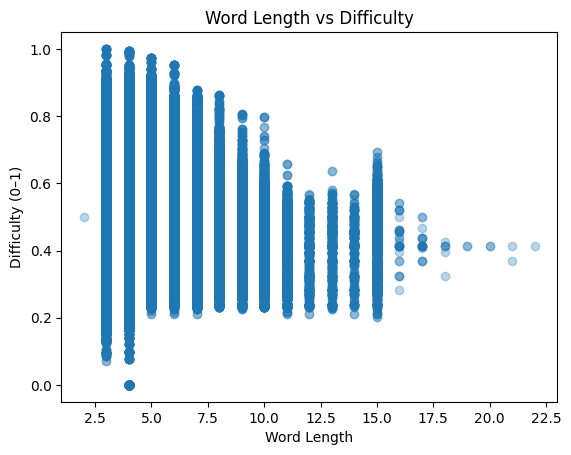

In [69]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    df_analyzed["Word_Length"],
    df_analyzed["Difficulty"],
    alpha=0.3
)

plt.xlabel("Word Length")
plt.ylabel("Difficulty (0–1)")
plt.title("Word Length vs Difficulty")

plt.show()


In [70]:
def minmax_safe(x):
    if x.max() == x.min():
        return 0.5  # neutral difficulty
    return (x - x.min()) / (x.max() - x.min())

df_analyzed["Difficulty_By_Length"] = (
    df_analyzed
    .groupby("Word_Length")["Difficulty"]
    .transform(minmax_safe)
)
df_analyzed

,Date,Word,Clue,Word_Length,Difficulty,Difficulty_By_Length
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,0.607383,0.577617
1,10/31/2021,RASCALS,Mischief-makers,7,0.483221,0.407035
2,10/31/2021,PEN,It might click for a writer,3,0.61745,0.588448
3,10/31/2021,SEP,Fall mo.,3,0.684564,0.66065
4,10/31/2021,ECO,Kind to Mother Nature,3,0.587248,0.555957
...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,0.869128,0.859206
781569,11/21/1993,SHRED,Bit,5,0.855705,0.845815
781570,11/21/1993,NEA,Teachers' org.,3,0.553691,0.519856
781571,11/21/1993,BEG,Petition,3,0.704698,0.68231


In [75]:
(
    df_analyzed
    .loc[df_analyzed["Word_Length"] == 4]
    .sort_values("Difficulty_By_Length")      # easiest first within 4-letter words
    .drop_duplicates(subset=["Word"])          # unique words
    [["Word", "Clue", "Difficulty_By_Length"]]
    .head(35)
)


,Word,Clue,Difficulty_By_Length
498285,ALAI,Jai ___,0.0
406784,AREA,"Length x width, for a rectangle",0.077703
29079,OSLO,Norway's capital,0.097973
108460,EDEN,Genesis garden,0.141892
160367,ERIE,One of the Great Lakes,0.148649
452860,ARIA,Diva's solo,0.152027
683214,ALOE,___ vera,0.165541
505846,ELSE,"""If all ___ fails ...""",0.168919
346663,ANTE,Opening stake,0.175676
389073,OREO,Creme-filled cookie,0.179054


In [77]:
df_analyzed["Difficulty_By_Length_Q"] = (
    df_analyzed
    .groupby("Word_Length")["Difficulty"]
    .transform(lambda x: x.rank(pct=True))
)
df_analyzed

,Date,Word,Clue,Word_Length,Difficulty,Difficulty_By_Length,Difficulty_By_Length_Q
0,10/31/2021,PAT,"Action done while saying ""Good dog""",3,0.607383,0.577617,0.552557
1,10/31/2021,RASCALS,Mischief-makers,7,0.483221,0.407035,0.353077
2,10/31/2021,PEN,It might click for a writer,3,0.61745,0.588448,0.578548
3,10/31/2021,SEP,Fall mo.,3,0.684564,0.66065,0.744025
4,10/31/2021,ECO,Kind to Mother Nature,3,0.587248,0.555957,0.485928
...,...,...,...,...,...,...,...
781568,11/21/1993,NAT,Actor Pendleton,3,0.869128,0.859206,0.994561
781569,11/21/1993,SHRED,Bit,5,0.855705,0.845815,0.996080
781570,11/21/1993,NEA,Teachers' org.,3,0.553691,0.519856,0.406764
781571,11/21/1993,BEG,Petition,3,0.704698,0.68231,0.790391


In [78]:
(
    df_analyzed
    .loc[df_analyzed["Word_Length"] == 4]
    .sort_values("Difficulty_By_Length_Q")      # easiest first within 4-letter words
    .drop_duplicates(subset=["Word"])          # unique words
    [["Word", "Clue", "Difficulty_By_Length_Q"]]
    .head(35)
)

,Word,Clue,Difficulty_By_Length_Q
498285,ALAI,Jai ___,0.000255
406784,AREA,"Length x width, for a rectangle",0.000535
29079,OSLO,Norway's capital,0.000633
108460,EDEN,Genesis garden,0.000815
160367,ERIE,One of the Great Lakes,0.000867
452860,ARIA,Diva's solo,0.000902
683214,ALOE,___ vera,0.001018
505846,ELSE,"""If all ___ fails ...""",0.001128
346663,ANTE,Opening stake,0.001288
389073,OREO,Creme-filled cookie,0.001367


In [82]:
import pandas as pd

# Ensure Date is datetime for proper "most recent"
df_analyzed["Date_dt"] = pd.to_datetime(df_analyzed["Date"], errors="coerce")

# 1) Drop Word==Clue, then keep only the most recent row for each (Word, Clue)
df_labeled = (
    df_analyzed
    .loc[df_analyzed["Word"] != df_analyzed["Clue"]]
    .sort_values("Date_dt")                          # oldest -> newest
    .drop_duplicates(subset=["Word", "Clue"], keep="last")  # keep most recent
    .copy()
)

# 2) Percentile within each Word_Length (based on Difficulty_By_Length)
df_labeled["Difficulty_Percentile_By_Length"] = (
    df_labeled
    .groupby("Word_Length")["Difficulty_By_Length"]
    .transform(lambda x: x.rank(pct=True))
)

# 3) Label buckets
def label_difficulty(p):
    if p <= 0.20:
        return "EASY"
    elif p <= 0.40:
        return "FAIR"
    elif p <= 0.60:
        return "MODERATE"
    elif p <= 0.80:
        return "HARD"
    else:
        return "DIFFICULT"

df_labeled["Difficulty_Label"] = df_labeled["Difficulty_Percentile_By_Length"].apply(label_difficulty)

# Optional: view
df_labeled[["Date", "Word", "Clue", "Word_Length", "Difficulty_By_Length",
            "Difficulty_Percentile_By_Length", "Difficulty_Label"]]


,Date,Word,Clue,Word_Length,Difficulty_By_Length,Difficulty_Percentile_By_Length,Difficulty_Label
781475,11/21/1993,STRIVE,Make a big effort,6,0.579186,0.886082,DIFFICULT
781476,11/21/1993,DAMASK,"Table linen, often",6,0.61086,0.927470,DIFFICULT
781480,11/21/1993,INV,"Edison, e.g.: Abbr.",3,0.534296,0.450655,MODERATE
781483,11/21/1993,SCREEN,Basketball ploy,6,0.606335,0.922109,DIFFICULT
781485,11/21/1993,ENTRAPS,Lures into wrongdoing,7,0.638191,0.917144,DIFFICULT
...,...,...,...,...,...,...,...
94,10/31/2021,IDEE,"Concept, in Cannes",4,0.597973,0.569516,MODERATE
95,10/31/2021,LEST,Just in case,4,0.611486,0.614297,HARD
96,10/31/2021,LASS,Glasgow gal,4,0.422297,0.202030,FAIR
98,10/31/2021,MOOT,___ court,4,0.570946,0.476826,MODERATE


In [83]:
df_final = (
    df_labeled.loc[:, ["Date", "Word", "Clue", "Difficulty_Label"]]
    .rename(columns={"Difficulty_Label": "Difficulty"})
    .copy()
)

df_final.head()


,Date,Word,Clue,Difficulty
781475,11/21/1993,STRIVE,Make a big effort,DIFFICULT
781476,11/21/1993,DAMASK,"Table linen, often",DIFFICULT
781480,11/21/1993,INV,"Edison, e.g.: Abbr.",MODERATE
781483,11/21/1993,SCREEN,Basketball ploy,DIFFICULT
781485,11/21/1993,ENTRAPS,Lures into wrongdoing,DIFFICULT


In [85]:
df_final[df_final["Word"].str.len() < 3]



,Date,Word,Clue,Difficulty
485629,6/12/2004,PI,It's just past three,DIFFICULT


In [86]:
df_final[df_final["Word"].str.contains(r"[^A-Za-z]", regex=True)]


,Date,Word,Clue,Difficulty
610257,12/31/1999,Y2K,Kind of bug,FAIR
610245,12/31/1999,H2O,"Rain, essentially",MODERATE
532706,10/9/2002,1AM,"When ""S.N.L."" wraps in N.Y.C.",EASY
449931,9/22/2005,A&E,Cable channel,EASY
449961,9/22/2005,A&M,Texas school,EASY
408485,3/18/2007,R&R,It's typically off base,EASY
408468,3/18/2007,S&L,Cousin of a credit union,EASY
408450,3/18/2007,A&E,"""American Justice"" network",FAIR
408499,3/18/2007,R&B,Music category,EASY
408557,3/18/2007,B&B,Offerer of cozy accommodations,EASY


In [87]:
# Keep only words with 3+ letters AND only A–Z characters
mask_keep = (
    df_final["Word"].str.len().ge(3) &
    df_final["Word"].str.fullmatch(r"[A-Za-z]+")
)

df_final = df_final[mask_keep].copy()


In [88]:
df_final

,Date,Word,Clue,Difficulty
781475,11/21/1993,STRIVE,Make a big effort,DIFFICULT
781476,11/21/1993,DAMASK,"Table linen, often",DIFFICULT
781480,11/21/1993,INV,"Edison, e.g.: Abbr.",MODERATE
781483,11/21/1993,SCREEN,Basketball ploy,DIFFICULT
781485,11/21/1993,ENTRAPS,Lures into wrongdoing,DIFFICULT
...,...,...,...,...
94,10/31/2021,IDEE,"Concept, in Cannes",MODERATE
95,10/31/2021,LEST,Just in case,HARD
96,10/31/2021,LASS,Glasgow gal,FAIR
98,10/31/2021,MOOT,___ court,MODERATE


In [89]:
df_final.to_csv("crosswords.csv", index=False)

In [90]:
import pandas as pd

# Parse Date (if not already datetime)
df_final["Date_dt"] = pd.to_datetime(df_final["Date"], errors="coerce")

# Filter: 2012+ and Monday
df_export = df_final[
    (df_final["Date_dt"].dt.year >= 2012) &
    (df_final["Date_dt"].dt.day_name() == "Monday")
].copy()

# Drop helper column if you don't want it in CSV
df_export = df_export.drop(columns=["Date_dt"])

# Export to CSV
df_export.to_csv("2012nytmondays.csv", index=False)


In [91]:
df_export

,Date,Word,Clue,Difficulty
274264,1/2/2012,LIRAS,Bygone Italian coins,EASY
274276,1/2/2012,DREAR,"Gloomy, to a bard",EASY
274262,1/2/2012,LMN,Trio between K and O,EASY
274263,1/2/2012,UNDERTHECOUNTER,Secret or illegal,EASY
274268,1/2/2012,REPO,"""___ Man"" (Emilio Estevez film)",EASY
...,...,...,...,...
523,10/25/2021,SPIN,Whirl or twirl,EASY
524,10/25/2021,ENT,Sinus doc,FAIR
525,10/25/2021,SCYTHE,Grim Reaper's implement,EASY
526,10/25/2021,REI,Big retailer of outdoor gear,EASY
